# ⚡***Energy Revolution: From Coal to Clean Power***

## INTRODUCTION

The global energy landscape is undergoing one of the most significant transformations in modern history. 
As countries worldwide commit to net-zero emissions targets, understanding the pace and patterns of 
renewable energy adoption has become critical for policymakers, investors, and energy professionals.

This project analyzes 25 years of global electricity generation data (2000-2024) to uncover trends in 
renewable energy adoption across 231 countries. By examining the rise of solar, wind, and hydroelectric 
power alongside the decline of fossil fuels, we gain insights into the trajectory of the global energy 
transition.

## Project Objective

This project analyzes the global shift from fossil fuels to renewable energy sources over the past 25 years (2000-2024). Using comprehensive energy data across 231 countries, we explore patterns, trends, and insights into the renewable energy transition worldwide.

### Objectives
1. **Understand global renewable energy adoption** - Track growth patterns across regions
2. **Compare renewable sources** - Analyze solar, wind, hydro, and other renewable contributions
3. **Identify regional leaders** - Which countries are leading the energy transition?
4. **Visualize trends** - Create compelling visualizations to tell the story
5. **Derive actionable insights** - What can we learn about the future of energy?

### Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
power = pd.read_csv('renewable_energy_share_2000_2025.csv')
power

,country,year,iso_code,population,gdp,primary_energy_consumption,electricity_generation,electricity_demand,renewables_share_energy,renewables_share_elec,...,solar_share_elec,wind_share_elec,hydro_share_elec,nuclear_share_elec,coal_share_elec,gas_share_elec,energy_per_capita,renewables_energy_per_capita,fossil_energy_per_capita,renewables_cons_change_twh
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,378.76,378.76,NaN,19.334,...,0.000,0.0,13.314,0.0,20.073,43.368,NaN,NaN,NaN,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,405.09,405.09,NaN,19.055,...,0.000,0.0,13.412,0.0,21.294,47.004,NaN,NaN,NaN,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,433.19,433.19,NaN,17.667,...,0.000,0.0,12.304,0.0,21.568,48.228,NaN,NaN,NaN,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,458.30,458.30,NaN,16.668,...,0.000,0.0,11.610,0.0,22.258,49.424,NaN,NaN,NaN,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,496.61,496.61,NaN,15.696,...,0.000,0.0,10.670,0.0,23.159,49.165,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7631,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,33.586,6.71,8.69,NaN,58.569,...,0.298,0.0,56.781,0.0,40.835,0.000,2163.068,NaN,NaN,NaN
7632,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,37.636,8.57,10.31,NaN,70.712,...,0.233,0.0,69.195,0.0,29.288,0.000,2382.434,NaN,NaN,NaN
7633,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,58.380,8.94,10.85,NaN,67.338,...,0.336,0.0,65.772,0.0,32.662,0.000,3633.067,NaN,NaN,NaN
7634,Zimbabwe,2023,ZWE,16340829.0,NaN,51.986,9.99,11.99,NaN,56.156,...,0.300,0.0,54.655,0.0,43.844,0.000,3181.361,NaN,NaN,NaN


### Data Exploration

In [3]:
power.info()

<class 'pandas.DataFrame'>
RangeIndex: 7636 entries, 0 to 7635
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       7636 non-null   str    
 1   year                          7636 non-null   int64  
 2   iso_code                      5549 non-null   str    
 3   population                    5846 non-null   float64
 4   gdp                           3800 non-null   float64
 5   primary_energy_consumption    6582 non-null   float64
 6   electricity_generation        6353 non-null   float64
 7   electricity_demand            6028 non-null   float64
 8   renewables_share_energy       2775 non-null   float64
 9   renewables_share_elec         6327 non-null   float64
 10  fossil_share_energy           2775 non-null   float64
 11  fossil_share_elec             6227 non-null   float64
 12  low_carbon_share_energy       2775 non-null   float64
 13  low_carbon_sha

In [4]:
null = power.isnull().sum()
null
#null[20:32]

country                            0
year                               0
iso_code                        2087
population                      1790
gdp                             3836
primary_energy_consumption      1054
electricity_generation          1283
electricity_demand              1608
renewables_share_energy         4861
renewables_share_elec           1309
fossil_share_energy             4861
fossil_share_elec               1409
low_carbon_share_energy         4861
low_carbon_share_elec           1309
solar_electricity               1301
wind_electricity                1509
hydro_electricity               1378
nuclear_electricity             1452
coal_electricity                1468
gas_electricity                 1566
oil_electricity                 1384
biofuel_electricity             1649
other_renewable_electricity     1311
solar_share_elec                1327
wind_share_elec                 1535
hydro_share_elec                1404
nuclear_share_elec              1478
c

In [5]:
# Dataset Information
print('Dataset Information:')
print()
print('Total Records:', len(power))
print('Total Columns:', len(power.columns))
print('Time Range:', power["year"].min(), 'to', power["year"].max())
print('Unique Countries/Regions:', power["country"].nunique())
print()
print('Date Range Coverage:', power["year"].max() - power["year"].min(), 'years')

Dataset Information:

Total Records: 7636
Total Columns: 33
Time Range: 2000 to 2025
Unique Countries/Regions: 309

Date Range Coverage: 25 years


### Data cleaning

In [6]:
# Removing rows where countries name is not available
power = power.dropna(subset=['iso_code'])

# Removing incomplete year 2025 for better data quality 
power = power[power['year'] < 2025]

power 

,country,year,iso_code,population,gdp,primary_energy_consumption,electricity_generation,electricity_demand,renewables_share_energy,renewables_share_elec,...,solar_share_elec,wind_share_elec,hydro_share_elec,nuclear_share_elec,coal_share_elec,gas_share_elec,energy_per_capita,renewables_energy_per_capita,fossil_energy_per_capita,renewables_cons_change_twh
26,Afghanistan,2000,AFG,20130334.0,1.128379e+10,5.288,0.48,0.57,NaN,64.583,...,0.000,0.0,64.583,0.0,0.000,0.0,262.680,NaN,NaN,NaN
27,Afghanistan,2001,AFG,20284303.0,1.102127e+10,3.649,0.69,0.78,NaN,72.464,...,0.000,0.0,72.464,0.0,5.797,0.0,179.892,NaN,NaN,NaN
28,Afghanistan,2002,AFG,21378123.0,1.880487e+10,3.328,0.71,0.81,NaN,78.873,...,0.000,0.0,78.873,0.0,5.634,0.0,155.695,NaN,NaN,NaN
29,Afghanistan,2003,AFG,22733053.0,2.107434e+10,3.968,0.91,1.01,NaN,69.231,...,0.000,0.0,69.231,0.0,9.890,0.0,174.558,NaN,NaN,NaN
30,Afghanistan,2004,AFG,23560656.0,2.233257e+10,3.717,0.79,0.89,NaN,70.886,...,0.000,0.0,70.886,0.0,7.595,0.0,157.758,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7631,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,33.586,6.71,8.69,NaN,58.569,...,0.298,0.0,56.781,0.0,40.835,0.0,2163.068,NaN,NaN,NaN
7632,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,37.636,8.57,10.31,NaN,70.712,...,0.233,0.0,69.195,0.0,29.288,0.0,2382.434,NaN,NaN,NaN
7633,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,58.380,8.94,10.85,NaN,67.338,...,0.336,0.0,65.772,0.0,32.662,0.0,3633.067,NaN,NaN,NaN
7634,Zimbabwe,2023,ZWE,16340829.0,NaN,51.986,9.99,11.99,NaN,56.156,...,0.300,0.0,54.655,0.0,43.844,0.0,3181.361,NaN,NaN,NaN


In [7]:
# Keeping only important columns
imp_columns = ['country', 'year', 'iso_code', 'population','electricity_generation', 'electricity_demand',
    'renewables_share_elec', 'fossil_share_elec','solar_electricity', 'wind_electricity',
    'hydro_electricity','coal_electricity', 'gas_electricity', 'oil_electricity', 'nuclear_electricity']

power = power[imp_columns]
power

,country,year,iso_code,population,electricity_generation,electricity_demand,renewables_share_elec,fossil_share_elec,solar_electricity,wind_electricity,hydro_electricity,coal_electricity,gas_electricity,oil_electricity,nuclear_electricity
26,Afghanistan,2000,AFG,20130334.0,0.48,0.57,64.583,35.417,0.00,0.0,0.31,0.00,0.0,0.17,0.0
27,Afghanistan,2001,AFG,20284303.0,0.69,0.78,72.464,27.536,0.00,0.0,0.50,0.04,0.0,0.15,0.0
28,Afghanistan,2002,AFG,21378123.0,0.71,0.81,78.873,21.127,0.00,0.0,0.56,0.04,0.0,0.11,0.0
29,Afghanistan,2003,AFG,22733053.0,0.91,1.01,69.231,30.769,0.00,0.0,0.63,0.09,0.0,0.19,0.0
30,Afghanistan,2004,AFG,23560656.0,0.79,0.89,70.886,29.114,0.00,0.0,0.56,0.06,0.0,0.17,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7631,Zimbabwe,2020,ZWE,15526887.0,6.71,8.69,58.569,41.431,0.02,0.0,3.81,2.74,0.0,0.04,0.0
7632,Zimbabwe,2021,ZWE,15797220.0,8.57,10.31,70.712,29.288,0.02,0.0,5.93,2.51,0.0,0.00,0.0
7633,Zimbabwe,2022,ZWE,16069061.0,8.94,10.85,67.338,32.662,0.03,0.0,5.88,2.92,0.0,0.00,0.0
7634,Zimbabwe,2023,ZWE,16340829.0,9.99,11.99,56.156,43.844,0.03,0.0,5.46,4.38,0.0,0.00,0.0


In [19]:
# output_file = 'D:\Data Analysis\Projects\Renewable Energy Share By Country\Energy share Cleaned Dataset.csv'
# power.to_csv(output_file,index=False)

### Data Analysis

In [9]:
# Descriptive statistics for key metrics
print('Statistics - Renewable Energy Share in Electricity (%)')
print(power['renewables_share_elec'].describe())
print()
print()
print('Statistics - Total Electricity Generation (TWh)')
print(power['electricity_generation'].describe())

Statistics - Renewable Energy Share in Electricity (%)
count    5271.000000
mean       31.174862
std        32.740693
min         0.000000
25%         1.813500
50%        18.421000
75%        55.187000
max       100.000000
Name: renewables_share_elec, dtype: float64


Statistics - Total Electricity Generation (TWh)
count     5297.000000
mean       106.067468
std        502.927609
min          0.000000
25%          0.710000
50%          7.220000
75%         44.310000
max      10086.880000
Name: electricity_generation, dtype: float64


In [10]:
# Global renewable energy trend
global_trend = power.groupby('year').agg({'solar_electricity': 'sum','wind_electricity': 'sum',
    'hydro_electricity': 'sum', 'coal_electricity': 'sum', 'gas_electricity': 'sum', 
    'oil_electricity': 'sum', 'nuclear_electricity': 'sum','electricity_generation': 'sum'}).reset_index()

# Calculate renewable share percentage
global_trend['renewable_total'] = (global_trend['solar_electricity'] + global_trend['wind_electricity'] + 
                                   global_trend['hydro_electricity']+ global_trend['oil_electricity'])
global_trend['renewables_share'] = (global_trend['renewable_total'] / global_trend['electricity_generation'] * 100)

print('Global Renewable Energy Trend:')
global_trend[['year', 'renewable_total', 'renewables_share']].tail(10)

Global Renewable Energy Trend:


,year,renewable_total,renewables_share
15,2015,6100.82,25.424162
16,2016,6387.28,25.871541
17,2017,6631.67,26.072979
18,2018,6928.34,26.185697
19,2019,7201.27,26.844387
20,2020,7567.30,28.324359
21,2021,8041.32,28.462764
22,2022,8651.71,29.925571
23,2023,9079.09,30.719334
24,2024,9912.30,32.169256


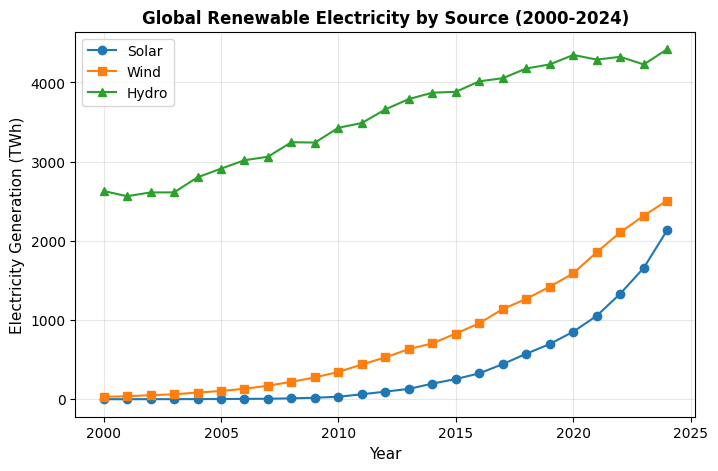

In [11]:
# Global renewable energy growth
plt.figure(figsize=(8, 5))
plt.plot(global_trend['year'], global_trend['solar_electricity'], marker='o', label='Solar')
plt.plot(global_trend['year'], global_trend['wind_electricity'], marker='s', label='Wind')
plt.plot(global_trend['year'], global_trend['hydro_electricity'], marker='^', label='Hydro')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Electricity Generation (TWh)', fontsize=11)
plt.title('Global Renewable Electricity by Source (2000-2024)', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

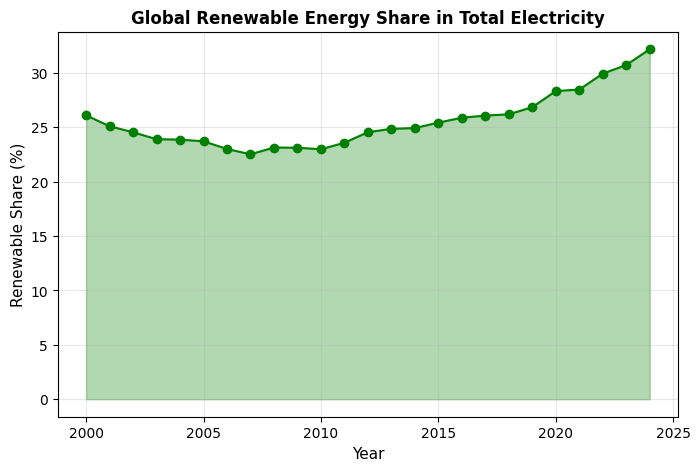

In [12]:
# Percentage share
plt.figure(figsize=(8, 5))
plt.plot(global_trend['year'], global_trend['renewables_share'], marker='o', color='green', markersize=6)
plt.fill_between(global_trend['year'], global_trend['renewables_share'], alpha=0.3, color='green')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Renewable Share (%)', fontsize=11)
plt.title('Global Renewable Energy Share in Total Electricity', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

In [13]:
print('Renewable Energy Growth:')

print('Solar (2000):', global_trend[global_trend["year"]==2000]["solar_electricity"].values[0], 'TWh')
print('Solar (2024):', global_trend[global_trend["year"]==2024]["solar_electricity"].values[0], 'TWh')

Renewable Energy Growth:
Solar (2000): 1.02 TWh
Solar (2024): 2135.9700000000003 TWh


In [14]:
# Get latest year data
latest_year = power['year'].max()
latest_data = power[power['year'] == latest_year].copy()

# Top countries by renewable share
top_renewable = latest_data.nlargest(15, 'renewables_share_elec')[['country', 'renewables_share_elec', 'electricity_generation']]

print('Top 15 Countries by Renewable Energy Share', (latest_year))
print(top_renewable.to_string(index=False))

Top 15 Countries by Renewable Energy Share 2024
                     country  renewables_share_elec  electricity_generation
                     Albania                100.000                    8.34
                      Bhutan                100.000                   11.00
Democratic Republic of Congo                100.000                   15.92
                    Ethiopia                100.000                   25.20
                     Iceland                100.000                   19.05
                       Nepal                100.000                   11.13
                    Paraguay                100.000                   42.41
                  Costa Rica                 99.909                   11.00
                     Uruguay                 98.878                   13.37
                      Norway                 98.606                  157.11
                     Namibia                 97.561                    1.64
                      Uganda            

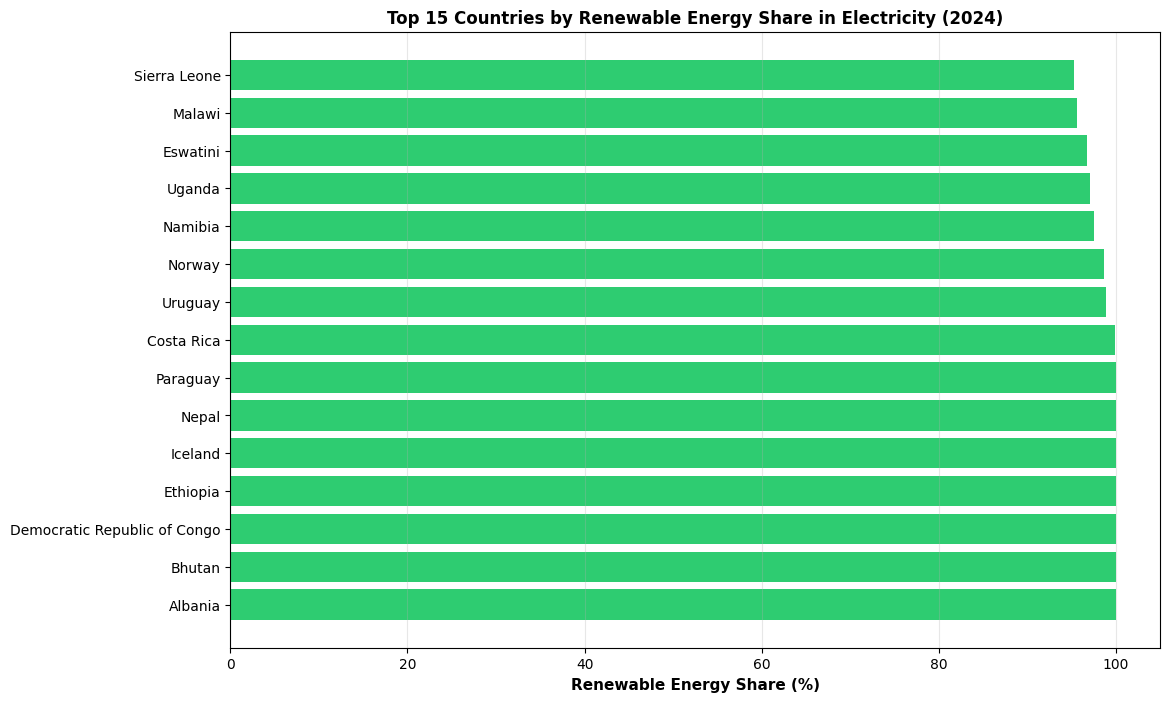

In [15]:
# Top 15 countries by renewable share
plt.figure(figsize=(12, 8))
top_15 = latest_data.nlargest(15, 'renewables_share_elec')
plt.barh(top_15['country'], top_15['renewables_share_elec'], color='#2ecc71')
plt.xlabel('Renewable Energy Share (%)', fontsize=11, fontweight='bold')
plt.title('Top 15 Countries by Renewable Energy Share in Electricity (2024)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

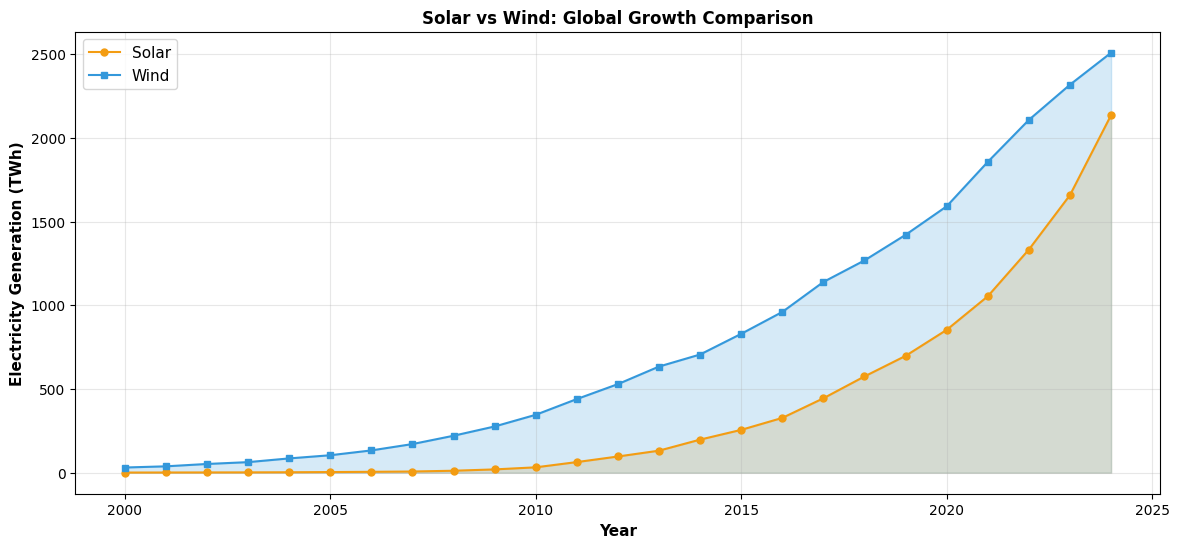

In [16]:
# Compare Solar vs Wind growth rates
plt.figure(figsize=(14, 6))
plt.plot(global_trend['year'], global_trend['solar_electricity'], marker='o', label='Solar', markersize=5, color='#f39c12')
plt.plot(global_trend['year'], global_trend['wind_electricity'], marker='s', label='Wind', markersize=5, color='#3498db')
plt.fill_between(global_trend['year'], global_trend['solar_electricity'], alpha=0.2, color='#f39c12')
plt.fill_between(global_trend['year'], global_trend['wind_electricity'], alpha=0.2, color='#3498db')
plt.xlabel('Year', fontsize=11, fontweight='bold')
plt.ylabel('Electricity Generation (TWh)', fontsize=11, fontweight='bold')
plt.title('Solar vs Wind: Global Growth Comparison', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

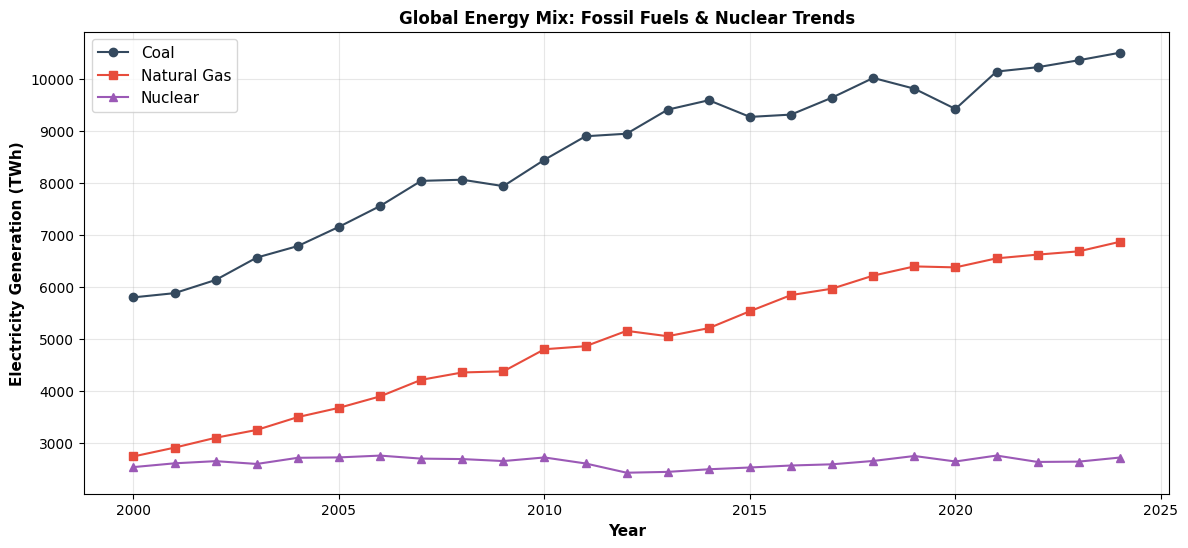

In [17]:
# Fossil fuel decline trend
plt.figure(figsize=(14, 6))
plt.plot(global_trend['year'], global_trend['coal_electricity'], marker='o', label='Coal', color='#34495e')
plt.plot(global_trend['year'], global_trend['gas_electricity'], marker='s', label='Natural Gas', color='#e74c3c')
plt.plot(global_trend['year'], global_trend['nuclear_electricity'], marker='^', label='Nuclear', color='#9b59b6')
plt.xlabel('Year', fontsize=11, fontweight='bold')
plt.ylabel('Electricity Generation (TWh)', fontsize=11, fontweight='bold')
plt.title('Global Energy Mix: Fossil Fuels & Nuclear Trends', fontsize=12, fontweight='bold')
plt.legend(fontsize=11,)
plt.grid(True, alpha=0.3)


## 4. Key Findings & Insights

### Key Observations:

1. **Explosive Solar Growth**
   - Solar electricity has grown exponentially, becoming one of the fastest-growing renewable sources
   - Driven by decreasing costs and technological improvements

2. **Wind Energy Acceleration**
   - Wind power continues to expand globally with consistent growth
   - Particularly strong in Europe and increasingly in Asia

3. **Regional Leaders**
   - Countries like Denmark, Germany, Brazil, and Norway are leading the transition
   - Hydro-rich countries maintain high renewable shares due to geography

4. **Coal's Decline**
   - Coal electricity is gradually decreasing in developed nations
   - Shift toward natural gas and renewables as transition fuels

5. **Global Progress**
   - Renewable energy share is increasing despite growing global electricity demand
   - The transition is real and accelerating, but coal still dominates in many regions

### Future Outlook:
- Continued growth in solar and wind capacity
- Storage solutions becoming critical for grid stability
- Emerging markets increasingly adopting renewables
- Policy and investment changes accelerating the transition

In [18]:
# Summary statistics
print('SUMMARY STATISTICS (2024):')

latest_data_2024 = power[power['year'] == 2024]

print()
print('Global Electricity Generation:', latest_data_2024["electricity_generation"].sum(), 'TWh')
print('Solar Generation:', latest_data_2024["solar_electricity"].sum(), 'TWh')
print('Wind Generation:', latest_data_2024["wind_electricity"].sum(), 'TWh')
print('Hydro Generation:', latest_data_2024["hydro_electricity"].sum(), 'TWh')
print('Coal Generation:', latest_data_2024["coal_electricity"].sum(), 'TWh')
print('Gas Generation:', latest_data_2024["gas_electricity"].sum(), 'TWh')
print('Nuclear Generation:', latest_data_2024["nuclear_electricity"].sum(), 'TWh')
print()

SUMMARY STATISTICS (2024):

Global Electricity Generation: 30812.96 TWh
Solar Generation: 2135.97 TWh
Wind Generation: 2508.63 TWh
Hydro Generation: 4419.37 TWh
Coal Generation: 10512.550000000001 TWh
Gas Generation: 6874.630000000001 TWh
Nuclear Generation: 2724.11 TWh



## 5. Conclusion

This analysis demonstrates that the global energy transition is **underway and accelerating**. While fossil fuels still dominate the global electricity mix, renewable energy sources—particularly solar and wind—are growing at exponential rates.

### Key Takeaways:
- Solar energy is the fastest-growing electricity source
- Wind energy provides stable, scalable renewable power
- Regional leaders prove the transition is achievable
- Investment and policy support are driving rapid change
- Challenges remain in energy storage and grid modernization

The data shows that achieving a 100% renewable energy future is technically possible, but requires sustained commitment, investment, and innovation across all nations.